## Comparison w/ and w/o filtered high frequency wave

### Import package

In [1]:
import os
import sys
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D



### Load data

In [2]:
# File path
file_path: Path = Path("/home/b11209013/KW_CRI/File")

# Load dispersion relation
disp_rel: dict[str, np.ndarray] = {

    "default"  : np.load(file_path / "Default.npy")[99:],
    "omega3=0" : np.load(file_path / "Omega^3=0.npy")[99:],
    "omega23=0": np.load(file_path / "Omega^3=0;Omega^2=0.npy")[99:]

}

# calculate wavenumber
k_dis: np.ndarray = np.linspace(0, 1e2, 10001)[100:]
k_cal: np.ndarray = 2*np.pi*4320/40000 * k_dis

### Visualize

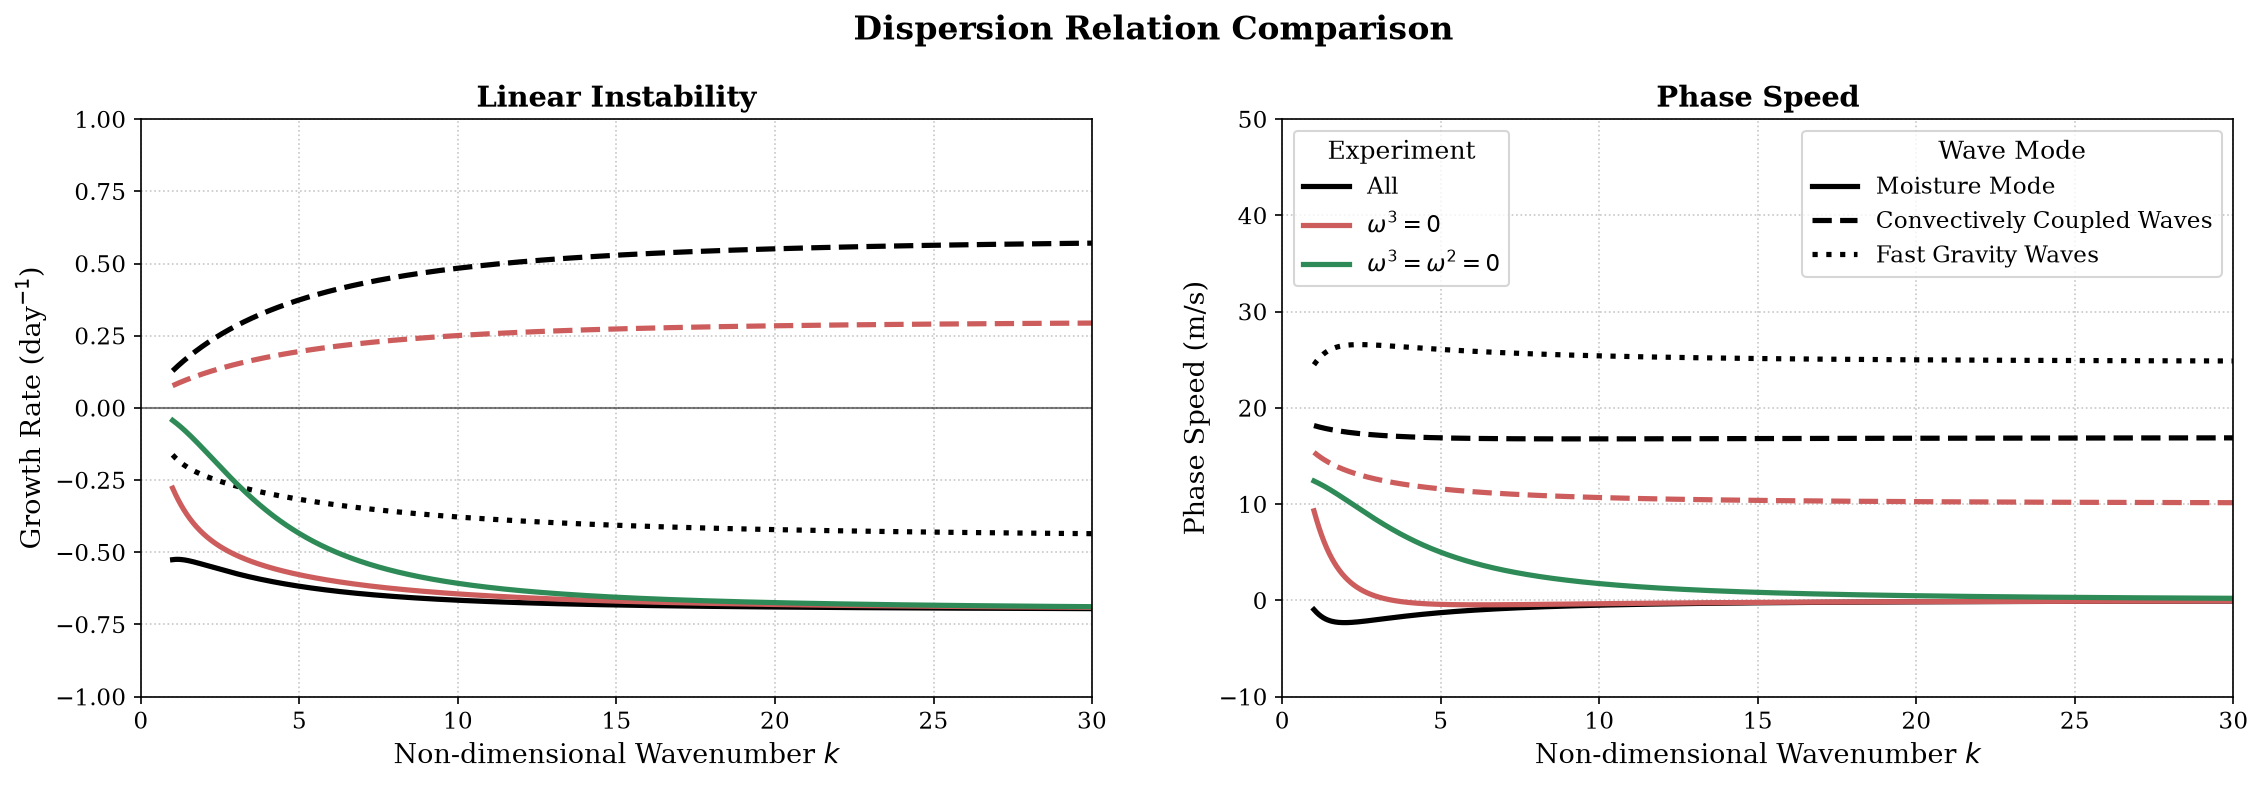

In [3]:
# ---------------------------------------------------------
# SETUP & STYLING
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif"
})

# Predefined lists
label_list = ["All", r"$\omega^3=0$", r"$\omega^3=\omega^2=0$"]
mode_list = ["Moisture Mode", "Convectively Coupled Waves", "Fast Gravity Waves"]
linestyle_list = ["-", "--", ":"]
color_list = ["k", "indianred", "seagreen"]
title = "Dispersion Relation Comparison"

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(18, 5), dpi=150)

# ---------------------------------------------------------
# DATA PLOTTING
# ---------------------------------------------------------
# Assuming disp_rel, k_dis, and k_cal are defined in your environment
for j, (key, value) in enumerate(disp_rel.items()):
    for i in range(value.shape[1]):
        # Subplot 1: Growth Rate
        ax[0].plot(k_dis, -value[:, i].imag, color=color_list[j], 
                   linestyle=linestyle_list[i], linewidth=2.5)
        
        # Subplot 2: Phase Speed
        phase_speed = (value[:, i].real / k_cal) * 50
        ax[1].plot(k_dis, phase_speed, color=color_list[j], 
                   linestyle=linestyle_list[i], linewidth=2.5)

# ---------------------------------------------------------
# SUBPLOT 1: LINEAR INSTABILITY (GROWTH RATE)
# ---------------------------------------------------------
ax[0].axhline(0, color="k", linestyle="-", linewidth=1, alpha=0.5) # Neutral stability line
ax[0].set_xlim(0, 30)
ax[0].set_ylim(-1, 1)
ax[0].set_ylabel("Growth Rate (day$^{-1}$)", fontsize=13)
ax[0].set_xlabel("Non-dimensional Wavenumber $k$", fontsize=13)
ax[0].set_title("Linear Instability", fontsize=14, fontweight="bold")
ax[0].grid(True, linestyle=":", alpha=0.7)
ax[0].tick_params(axis='both', labelsize=11)

# ---------------------------------------------------------
# SUBPLOT 2: PHASE SPEED
# ---------------------------------------------------------
ax[1].set_xlim(0, 30)
ax[1].set_ylim(-10, 50)
ax[1].set_ylabel("Phase Speed (m/s)", fontsize=13)
ax[1].set_xlabel("Non-dimensional Wavenumber $k$", fontsize=13)
ax[1].set_title("Phase Speed", fontsize=14, fontweight="bold")
ax[1].grid(True, linestyle=":", alpha=0.7)
ax[1].tick_params(axis='both', labelsize=11)

# ---------------------------------------------------------
# CUSTOM LEGENDS (Applied to right plot)
# ---------------------------------------------------------
# 1. Experiment Handles
experiment_handles = [
    Line2D([0], [0], color=c, lw=2.5, linestyle='-', label=l) 
    for c, l in zip(color_list, label_list)
]

# 2. Wave Mode Handles
mode_handles = [
    Line2D([0], [0], color='k', lw=2.5, linestyle=ls, label=l) 
    for ls, l in zip(linestyle_list, mode_list)
]

# Draw and lock first legend
leg_exp = ax[1].legend(handles=experiment_handles, title="Experiment", 
                       loc="upper left", frameon=True, fontsize=11, title_fontsize=12)
ax[1].add_artist(leg_exp) 

# Draw second legend
ax[1].legend(handles=mode_handles, title="Wave Mode", 
             loc="upper right", frameon=True, fontsize=11, title_fontsize=12)

# ---------------------------------------------------------
# FINAL ADJUSTMENTS
# ---------------------------------------------------------
plt.suptitle(title, fontsize=16, fontweight="bold", y=1.02)

# Optional: Save figure
plt.savefig("/home/b11209013/KW_CRI/Figure/filter_comparison.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)